# 第 12 章 · Digits GAN 代码实验

[章节网页](../ch12.html)

## 运行内容

- 加载 sklearn Digits
- 训练 PyTorch GAN
- 绘制生成样本

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# PyTorch GAN：在 sklearn Digits 真实手写数字上训练生成器和判别器。
gan_packages = {"torch": "torch>=2.2"}
missing = [package for module, package in gan_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import torch
from torch import nn

torch.manual_seed(7)
digits = load_digits()
real_digits = torch.tensor(digits.images / 16.0 * 2 - 1, dtype=torch.float32).reshape(-1, 64)
latent_dim = 16
batch_size = 96

generator = nn.Sequential(
    nn.Linear(latent_dim, 64),
    nn.ReLU(),
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.Tanh(),
)
discriminator = nn.Sequential(
    nn.Linear(64, 128),
    nn.LeakyReLU(0.2),
    nn.Linear(128, 64),
    nn.LeakyReLU(0.2),
    nn.Linear(64, 1),
)
loss_fn = nn.BCEWithLogitsLoss()
opt_g = torch.optim.Adam(generator.parameters(), lr=0.0015, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.0015, betas=(0.5, 0.999))
gan_rows = []

for step in range(1, 501):
    idx = torch.randint(0, len(real_digits), (batch_size,))
    real_batch = real_digits[idx]
    z = torch.randn(batch_size, latent_dim)
    fake_batch = generator(z).detach()

    real_logits = discriminator(real_batch)
    fake_logits = discriminator(fake_batch)
    d_loss = loss_fn(real_logits, torch.ones_like(real_logits)) + loss_fn(fake_logits, torch.zeros_like(fake_logits))
    opt_d.zero_grad()
    d_loss.backward()
    opt_d.step()

    z = torch.randn(batch_size, latent_dim)
    generated = generator(z)
    g_logits = discriminator(generated)
    g_loss = loss_fn(g_logits, torch.ones_like(g_logits))
    opt_g.zero_grad()
    g_loss.backward()
    opt_g.step()

    if step % 50 == 0:
        with torch.no_grad():
            gan_rows.append({
                "step": step,
                "D_loss": float(d_loss),
                "G_loss": float(g_loss),
                "D(real)": float(torch.sigmoid(discriminator(real_batch)).mean()),
                "D(fake)": float(torch.sigmoid(discriminator(generator(torch.randn(batch_size, latent_dim)))).mean()),
            })

with torch.no_grad():
    gan_samples = generator(torch.randn(16, latent_dim)).reshape(16, 8, 8).numpy()
gan_trace = pd.DataFrame(gan_rows)
display(gan_trace.round(3))

,step,D_loss,G_loss,D(real),D(fake)
0,50,0.987,1.270,0.738,0.471
1,100,1.065,1.513,0.635,0.341
2,150,0.690,1.415,0.764,0.310
3,200,0.849,1.669,0.781,0.416
4,250,0.415,4.273,0.891,0.139
5,300,0.389,2.870,0.867,0.160
6,350,0.695,1.904,0.823,0.302
7,400,0.744,1.971,0.790,0.394
8,450,0.711,4.101,0.738,0.074
9,500,0.465,2.726,0.843,0.199


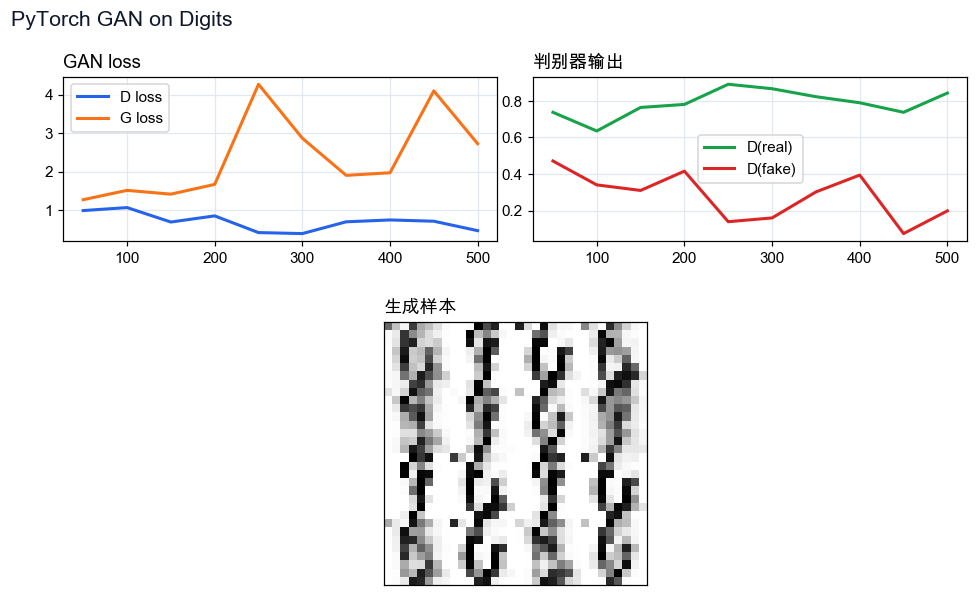

In [3]:
# 绘制训练曲线和生成的 digits 样本。
fig = plt.figure(figsize=(10.6, 6.0))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.6], hspace=0.38, wspace=0.18)
ax_loss = fig.add_subplot(gs[0, :2])
ax_score = fig.add_subplot(gs[0, 2:])
ax_loss.plot(gan_trace["step"], gan_trace["D_loss"], color="#2563eb", linewidth=2.0, label="D loss")
ax_loss.plot(gan_trace["step"], gan_trace["G_loss"], color="#f97316", linewidth=2.0, label="G loss")
ax_loss.set_title("GAN loss", loc="left", fontweight="bold")
ax_loss.grid(True, color="#e2e8f0", linewidth=0.8)
ax_loss.legend()

ax_score.plot(gan_trace["step"], gan_trace["D(real)"], color="#16a34a", linewidth=2.0, label="D(real)")
ax_score.plot(gan_trace["step"], gan_trace["D(fake)"], color="#dc2626", linewidth=2.0, label="D(fake)")
ax_score.set_title("判别器输出", loc="left", fontweight="bold")
ax_score.grid(True, color="#e2e8f0", linewidth=0.8)
ax_score.legend()

sample_tile = np.block([[gan_samples[i * 4 + j] for j in range(4)] for i in range(4)])
ax_img = fig.add_subplot(gs[1, :])
ax_img.imshow((sample_tile + 1) / 2, cmap="gray_r", vmin=0, vmax=1)
ax_img.set_title("生成样本", loc="left", fontweight="bold")
ax_img.set_xticks([])
ax_img.set_yticks([])
fig.suptitle("PyTorch GAN on Digits", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()